In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.ndimage import label
from skimage import morphology
from skimage import measure
from scipy import ndimage as ndi
from skimage.segmentation import find_boundaries
from scipy.stats import gaussian_kde
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import curve_fit
from scipy.ndimage import map_coordinates
import seaborn as sns
from scipy.ndimage import maximum_filter, label
from scipy.stats import skewnorm
from scipy.stats import lognorm

In [2]:
#Defining all the required functions

#Fourier Transform Functions
def partial_x_fft(f, dx):
    nx, ny = f.shape
    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
    f_fft = np.fft.fft(f, axis=0)
    df_fft = 1j * kx[:, None] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=0))

def partial_y_fft(f, dy):
    nx, ny = f.shape
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy)
    f_fft = np.fft.fft(f, axis=1)
    df_fft = 1j * ky[None, :] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=1))

#Defining constants
dx = 0.0625
dy = 0.0625

def compute_radial_spectrum(fld, dx, dy, dtype=float):
    nx, ny = fld.shape

    # Fourier wavenumbers
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K_perp = np.sqrt(KX**2 + KY**2)

    # Power spectrum density
    ff = np.abs(np.fft.ifft2(fld))**2   # use fft2, not ifft2
    P_flat = ff.ravel()
    K_flat = K_perp.ravel()

    # Radial bins
    dk = kx[1] - kx[0]
    k_bins = np.arange(0, np.max(K_flat) + dk, dk)
    nk = len(k_bins)
    P_k = np.zeros(nk, dtype=dtype)

    # Bin indices (vectorized)
    idx_float = K_flat / dk
    i1 = np.floor(idx_float).astype(int)
    i2 = i1 + 1
    w = idx_float - i1   # weight to upper bin

    # Accumulate into bins
    for i in range(len(K_flat)):
        if i1[i] >= 0 and i2[i] < nk:
            P_k[i1[i]] += P_flat[i] * (1 - w[i])
            P_k[i2[i]] += P_flat[i] * w[i]

    # Pack into recarray
    tags = ['kk', 'sp']
    sps = np.recarray((nk,), dtype=[(t, dtype) for t in tags])
    sps['kk'] = k_bins
    sps['sp'] = P_k / dk

    return sps

In [52]:
#Denoising the data
def gaussian_fft_filter_2d(J_squared, k0):
    """
    Apply a Gaussian low-pass filter in Fourier space to a 2D field.

    Parameters
    ----------
    J_squared : 2D numpy array
        Input real-space data
    k0 : float
        Filter width in k-space (grid units). Smaller = stronger smoothing.

    Returns
    -------
    J_filtered : 2D numpy array
        Smoothed real-space data
    """

    # FFT
    F = np.fft.fft2(J_squared)
    F_shifted = np.fft.fftshift(F)

    # k-grid
    nx, ny = J_squared.shape
    kx = np.fft.fftshift(np.fft.fftfreq(nx)) * nx
    ky = np.fft.fftshift(np.fft.fftfreq(ny)) * ny
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX**2 + KY**2

    # Gaussian filter in k-space
    gaussian = np.exp(-K2 / (2 * k0**2))

    # Apply filter
    F_filt = F_shifted * gaussian

    # Inverse FFT
    F_filt = np.fft.ifftshift(F_filt)
    J_filtered = np.fft.ifft2(F_filt)

    # Return real part
    return np.real(J_filtered)

def detect_current_sheets(mod_Jz):
    
    # size of grid
    nx, ny = mod_Jz.shape
    
    # global maximum |Jz|
    max_global = np.max(mod_Jz)
    
    # threshold to stop searching for new sheets
    global_threshold = 0.2 * max_global
    
    # keep track of points already assigned to sheets
    visited = np.zeros_like(mod_Jz, dtype=bool)
    
    # list to store all current sheets
    current_sheets = []

    while True:
        
        # mask out already visited cells
        masked_field = np.where(visited, -np.inf, mod_Jz)
        
        # location of largest remaining |Jz|
        max_index = np.unravel_index(np.argmax(masked_field), mod_Jz.shape)
        peak_value = mod_Jz[max_index]
        
        # stop condition
        if peak_value < global_threshold:
            break
        
        # threshold for this sheet
        local_threshold = 0.5 * peak_value
        
        # stack for depth-first search
        stack = [max_index]
        
        # store indices belonging to this sheet
        sheet_points = []
        
        while stack:
            
            i, j = stack.pop()
            
            if visited[i, j]:
                continue
            
            if mod_Jz[i, j] <= local_threshold:
                continue
            
            visited[i, j] = True
            sheet_points.append((i, j))
            
            # check 4 neighbors
            neighbors = [
                (i+1, j),
                (i-1, j),
                (i, j+1),
                (i, j-1)
            ]
            
            for ni, nj in neighbors:
                if 0 <= ni < nx and 0 <= nj < ny:
                    if not visited[ni, nj]:
                        stack.append((ni, nj))
        
        current_sheets.append(sheet_points)

    return current_sheets

In [53]:
#Lets Computer J_total

# # 1. Read the HDF5 file
File_Bx = '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_0.0625/beta_e_1/Bx_ApJ_t40.h5'  # Replace with your file path
File_By = '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_0.0625/beta_e_1/By_ApJ_t40.h5'  # Replace with your file path
File_Bz = '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_0.0625/beta_e_1/Bz_ApJ_t40.h5'  # Replace with your file path

with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy, h5py.File(File_Bz, 'r') as fBz:
    data_Bx = fBx['DS1'][:].T
    data_By = fBy['DS1'][:].T
    data_Bz = fBz['DS1'][:].T
    data_Bx_filtered = gaussian_fft_filter_2d(data_Bx, k0=0.2 * len(data_Bx))
    data_By_filtered = gaussian_fft_filter_2d(data_By, k0=0.2 * len(data_Bx))
    data_Bz_filtered = gaussian_fft_filter_2d(data_Bz, k0=0.2 * len(data_Bx))
    data_Jx = partial_y_fft(data_Bz_filtered,dx)
    data_Jy = -partial_x_fft(data_Bz_filtered,dy)
    data_Jz = partial_x_fft(data_By_filtered,dy)-partial_y_fft(data_Bx_filtered,dx)

J_squared = data_Jx**2 + data_Jy**2 + data_Jz**2

Jpar_squared = ((data_Jx*data_Bx + data_Jy*data_By + data_Jz*data_Bz)**2)/(data_Bx**2 + data_By**2 + data_Bz**2)
Jperp_squared = J_squared - Jpar_squared
mod_Jperp = np.sqrt(np.abs(Jperp_squared))
mod_Jperp = gaussian_fft_filter_2d(mod_Jperp, k0=0.2 * len(data_Bx))

In [54]:
sheets = detect_current_sheets(mod_Jperp)

In [55]:
cleaned_mask = np.zeros_like(mod_Jperp)

for sheet in sheets:
    for (i, j) in sheet:
        cleaned_mask[i, j] = 1

In [43]:
# #MORPHOLOGICAL SMOOTHING
# struct = morphology.disk(4)

# smoothed_mask = morphology.binary_opening(cleaned_mask, struct)
# smoothed_mask = morphology.binary_closing(smoothed_mask, struct)
# smoothed_mask = smoothed_mask.astype(int)

# #Remove small areas
# min_area = 100 # choose based on eye balling
# cleaned_mask = morphology.remove_small_objects(smoothed_mask.astype(bool), min_size=min_area).astype(int)

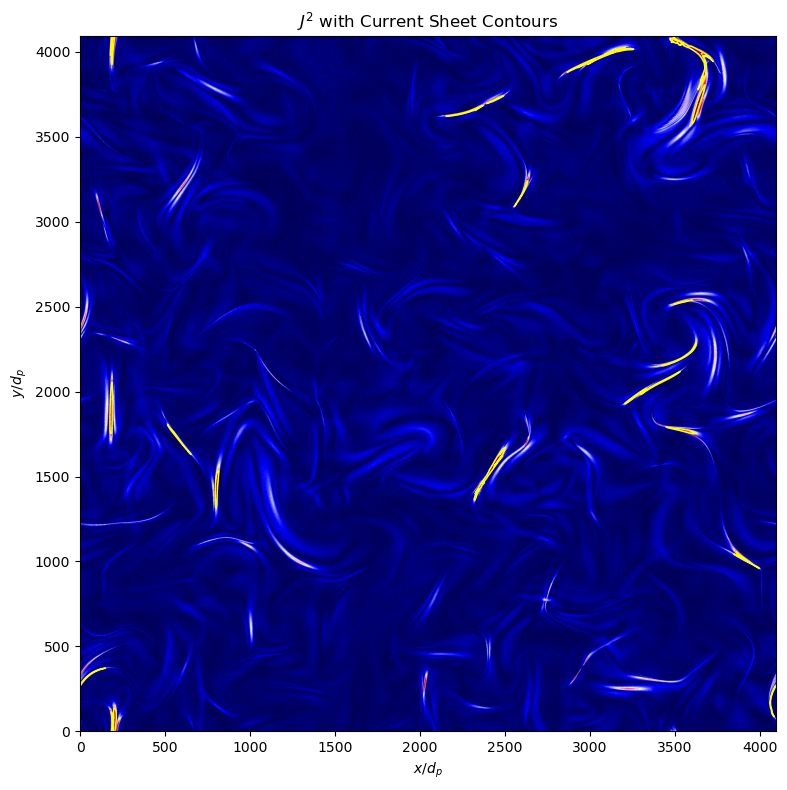

In [56]:
plt.figure(figsize=(10, 8))

# Base field
plt.imshow(mod_Jperp.T, cmap='seismic', origin='lower',vmax = 0.2)

# Current sheet contours
plt.contour(cleaned_mask.T, levels=[0.5], colors='yellow', linewidths=1)

plt.title(r'$J^{2}$ with Current Sheet Contours')
plt.xlabel(r'$x/d_p$')
plt.ylabel(r'$y/d_p$')

plt.tight_layout()
plt.savefig("J2_NR_with_CS_contours.png", dpi=300)

plt.show()

In [45]:
#FIND MAXIMUM IN EACH CONNECTED REGION

labeled_mask, num_features = label(cleaned_mask)
print("Regions found:", num_features)

max_coords = []
max_values = []

for i in range(1, num_features + 1):
    region_mask = (labeled_mask == i)
    region_vals = Jpar_squared[region_mask]

    if region_vals.size == 0:
        continue

    # Extreme value (max magnitude)
    max_pos = np.argmax(np.abs(region_vals))
    extreme_value = region_vals[max_pos]
    max_values.append(extreme_value)

    # Convert index → coordinates
    xs, ys = np.where(region_mask)
    max_coords.append((xs[max_pos], ys[max_pos]))

Regions found: 31


In [47]:
# Method 1 for Thickness Computation: Using the internal function for diameter of largest inscribed circle

#1. Labelling each connected region

labeled_mask = measure.label(cleaned_mask, connectivity=2)
num_regions = labeled_mask.max()
print("Number of connected regions:", num_regions)

#2. Compute thicknesses

thicknesses_m1 = []

for label_id in range(1, num_regions + 1):

    region = (labeled_mask == label_id)

    # Euclidean distance transform INSIDE the region
    dist = ndi.distance_transform_edt(region)

    # Full sheet thickness = diameter of largest inscribed circle
    thickness = 2 * dist.max()

    thicknesses_m1.append(thickness)

# 3. Some Central Measures of the statistics

print(f"Found {len(thicknesses_m1)} sheets")
print(f"Mean thickness = {np.mean(thicknesses_m1):.3f} pixels")
print(f"Median thickness = {np.median(thicknesses_m1):.3f} pixels")
print(f"Min thickness = {np.min(thicknesses_m1):.3f} px, Max = {np.max(thicknesses_m1):.3f} px")

Number of connected regions: 31
Found 31 sheets
Mean thickness = 37.142 pixels
Median thickness = 33.106 pixels
Min thickness = 8.944 px, Max = 121.852 px


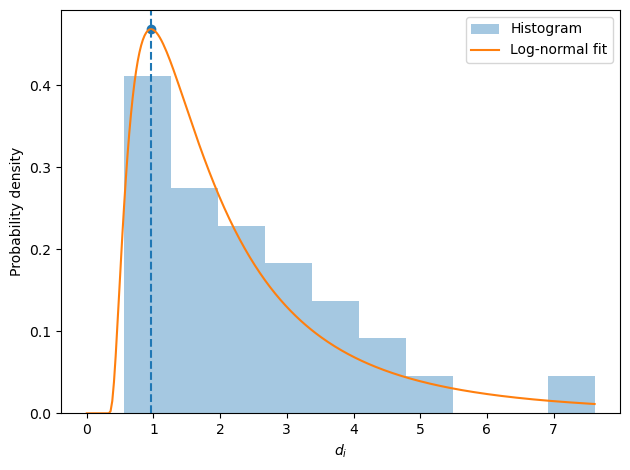

In [48]:
x = np.array(thicknesses_m1)   # in pixels
x = x[x > 0]

# Convert pixels -> d_i
x_di = x / 16.0

# Fit log-normal in d_i units
# shape, loc, scale = lognorm.fit(x_di, floc=0)
shape, loc, scale = lognorm.fit(x_di)

xs = np.linspace(0, x_di.max(), 300)

# Compute mode (peak of the PDF)
x_mode = loc + scale * np.exp(-shape**2)
y_mode = lognorm.pdf(x_mode, shape, loc, scale)

plt.hist(x_di, bins=10, density=True, alpha=0.4, label="Histogram")
plt.plot(xs, lognorm.pdf(xs, shape, loc, scale), label="Log-normal fit")

# Mark the peak
plt.axvline(x_mode, linestyle="--")
plt.scatter([x_mode], [y_mode])

plt.xlabel(r"$d_i$")
plt.ylabel("Probability density")
plt.legend()
plt.tight_layout()
plt.savefig("Jpar_PDF_beta0.0625.png", dpi=300)
plt.show()

In [14]:
#Different Strategies for Threshold
#Strategy 1: Pick top 10% of the features
threshold = np.quantile(Jperp_squared, 0.8)

print("Threshold:", threshold)

binary_mask = np.abs(Jperp_squared) > threshold


#MORPHOLOGICAL SMOOTHING
struct = morphology.disk(5)

smoothed_mask = morphology.binary_opening(binary_mask, struct)
smoothed_mask = morphology.binary_closing(smoothed_mask, struct)
smoothed_mask = smoothed_mask.astype(int)

#Remove small areas
min_area = 300 # choose based on eye balling
cleaned_mask = morphology.remove_small_objects(smoothed_mask.astype(bool), min_size=min_area).astype(int)

Threshold: 0.00039075863963037975


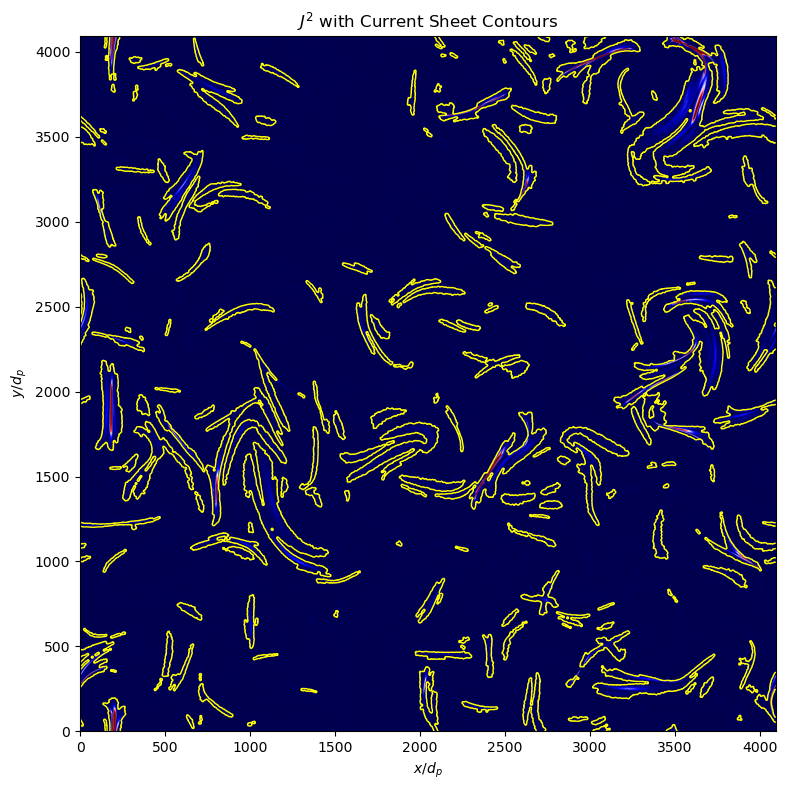

In [15]:
#Plot current sheets over the base J_squared field

plt.figure(figsize=(10, 8))

# Base field
plt.imshow(Jperp_squared.T, cmap='seismic', origin='lower', vmax=0.05)

# Add current-sheet boundaries
plt.contour(cleaned_mask.T, levels=[0.5], colors='yellow', linewidths=1)

plt.title(r'$J^{2}$ with Current Sheet Contours')
plt.xlabel(r'$x/d_p$')
plt.ylabel(r'$y/d_p$')
plt.tight_layout()
plt.savefig("Jperp_with_CS_contours_beta0.0625.png", dpi=300)
plt.show()

In [16]:
#FIND MAXIMUM IN EACH CONNECTED REGION

labeled_mask, num_features = label(cleaned_mask)
print("Regions found:", num_features)

max_coords = []
max_values = []

for i in range(1, num_features + 1):
    region_mask = (labeled_mask == i)
    region_vals = Jperp_squared[region_mask]

    if region_vals.size == 0:
        continue

    # Extreme value (max magnitude)
    max_pos = np.argmax(np.abs(region_vals))
    extreme_value = region_vals[max_pos]
    max_values.append(extreme_value)

    # Convert index → coordinates
    xs, ys = np.where(region_mask)
    max_coords.append((xs[max_pos], ys[max_pos]))

Regions found: 210


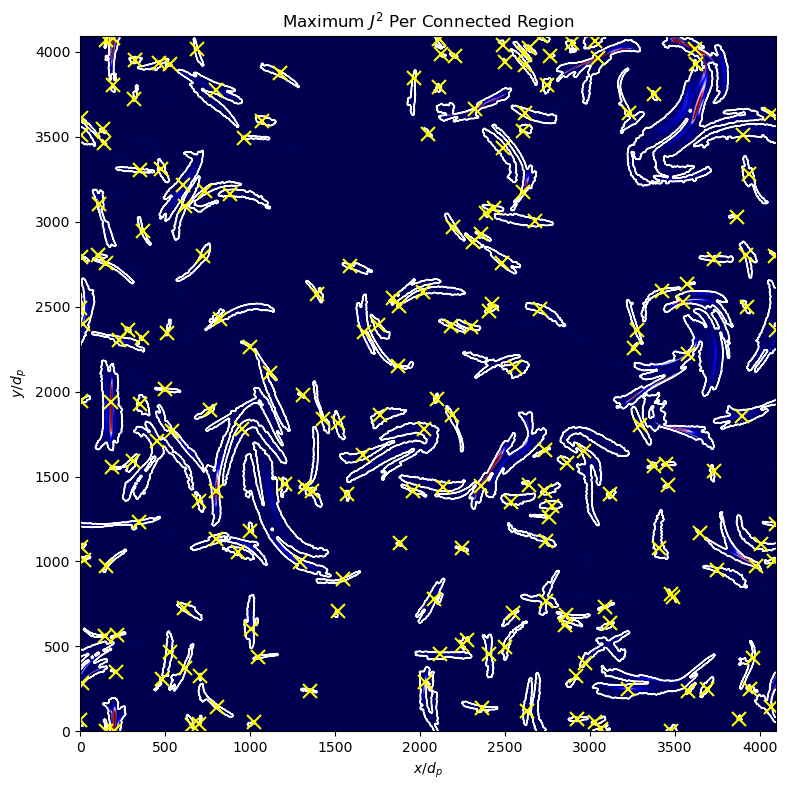

In [17]:
# PLOT ORIGINAL FIELD + MASK + MAXIMUM POINTS

plt.figure(figsize=(10, 8))

# --- Base field ---
plt.imshow(Jperp_squared.T, cmap='seismic', origin='lower', vmax=0.05)

# --- Boundaries of CSs---
boundaries = find_boundaries(labeled_mask)
plt.contour(boundaries.T, levels=[0.5], colors='white', linewidths=1)

# --- Overlay maxima as yellow crosses ---
for x, y in max_coords:
    plt.plot(x, y, marker='x', markersize=10, markeredgewidth=1.5, color='yellow')

plt.title(r'Maximum $J^{2}$ Per Connected Region')
plt.xlabel(r'$x/d_p$')
plt.ylabel(r'$y/d_p$')

plt.tight_layout()
plt.savefig("Jperp_maxima_overlay_beta0.0625.png", dpi=300)
plt.show()

In [18]:
# Method 1 for Thickness Computation: Using the internal function for diameter of largest inscribed circle

#1. Labelling each connected region

labeled_mask = measure.label(cleaned_mask, connectivity=2)
num_regions = labeled_mask.max()
print("Number of connected regions:", num_regions)

#2. Compute thicknesses

thicknesses_m1 = []

for label_id in range(1, num_regions + 1):

    region = (labeled_mask == label_id)

    # Euclidean distance transform INSIDE the region
    dist = ndi.distance_transform_edt(region)

    # Full sheet thickness = diameter of largest inscribed circle
    thickness = 2 * dist.max()

    thicknesses_m1.append(thickness)

# 3. Some Central Measures of the statistics

print(f"Found {len(thicknesses_m1)} sheets")
print(f"Mean thickness = {np.mean(thicknesses_m1):.3f} pixels")
print(f"Median thickness = {np.median(thicknesses_m1):.3f} pixels")
print(f"Min thickness = {np.min(thicknesses_m1):.3f} px, Max = {np.max(thicknesses_m1):.3f} px")

Number of connected regions: 210
Found 210 sheets
Mean thickness = 37.427 pixels
Median thickness = 29.120 pixels
Min thickness = 10.770 px, Max = 147.513 px


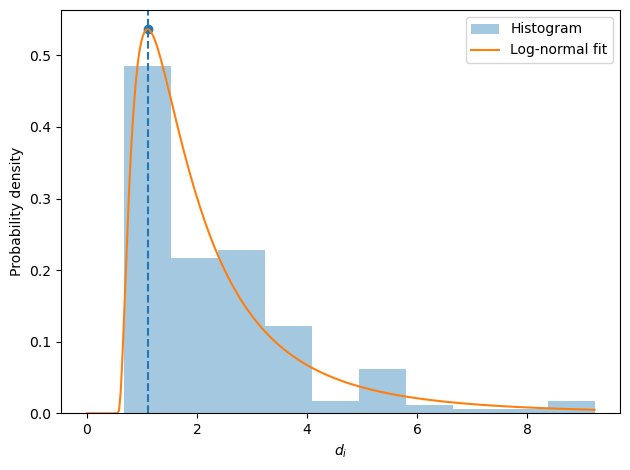

In [19]:
x = np.array(thicknesses_m1)   # in pixels
x = x[x > 0]

# Convert pixels -> d_i
x_di = x / 16.0

# Fit log-normal in d_i units
# shape, loc, scale = lognorm.fit(x_di, floc=0)
shape, loc, scale = lognorm.fit(x_di)

xs = np.linspace(0, x_di.max(), 300)

# Compute mode (peak of the PDF)
x_mode = loc + scale * np.exp(-shape**2)
y_mode = lognorm.pdf(x_mode, shape, loc, scale)

plt.hist(x_di, bins=10, density=True, alpha=0.4, label="Histogram")
plt.plot(xs, lognorm.pdf(xs, shape, loc, scale), label="Log-normal fit")

# Mark the peak
plt.axvline(x_mode, linestyle="--")
plt.scatter([x_mode], [y_mode])

plt.xlabel(r"$d_i$")
plt.ylabel("Probability density")
plt.legend()
plt.tight_layout()
plt.savefig("Jperp_PDF_beta0.0625.png", dpi=300)
plt.show()